## 📦 Importación de Librerías Necesarias

Se importan las bibliotecas fundamentales para el desarrollo del modelo de predicción basado en redes neuronales recurrentes (RNN), incluyendo Keras para la construcción del modelo (con capas GRU y LSTM), NumPy y pandas para manipulación de datos, herramientas de visualización como matplotlib y seaborn, así como utilidades para escalado de datos y guardado del modelo con `joblib`.

In [1]:
#IMPORTS NECESARIOS
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, ReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.random import set_seed as tf_seed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import joblib

## 📦 Importación de MLFlow

In [2]:
import mlflow
import mlflow.keras

ModuleNotFoundError: No module named 'mlflow'

## 🎲 Fijación de la Semilla Aleatoria

Se fija la semilla aleatoria de TensorFlow en 0 para asegurar la reproducibilidad de los resultados durante el entrenamiento del modelo. Esto permite obtener siempre los mismos resultados al ejecutar el notebook

In [ ]:
tf_seed(0)

## 🧠 Definición del Modelo GRU Personalizado

Se define la función `GRUHyperModel`, que construye una red neuronal secuencial basada en dos capas GRU. Esta arquitectura está pensada para tareas de predicción en series temporales. La primera capa GRU utiliza activación lineal y devuelve la secuencia completa a la siguiente capa, mientras que la segunda aplica una activación ReLU y devuelve solo la última salida. La capa final es densa y genera la predicción. El modelo se compila utilizando el optimizador Adam con parámetros configurables de tasa de aprendizaje y penalización por peso (`weight_decay`), y se entrena minimizando el error cuadrático medio (`mse`), con la métrica adicional del error absoluto medio (`mae`).

In [ ]:
def GRUHyperModel(input_shape, output_units, learning_rate = 0.01, weight_decay = 0.0001):  # , output_units se deja comentado dado que en principio solo queremos predecir un valor de tensión
    model = Sequential()
    
    # Capa GRU 1. Se puede modificar:
    # - units: número de neuronas en esta capa
    # - activation: función de activación, por defecto 'tanh'
    # - dropout: modificar entre 0.0 y 0.3 para evitar el sobreajuste
    model.add(LSTM(
        units = 16,
        activation='tanh',  # Se puede probar también tanh
        dropout=0.1,
        input_shape=input_shape, #Tamaño de la capa de entrada
        return_sequences = True #Este valor es importante para que devuelva la secuencia de horas
    ))

    model.add(LSTM(
        units = 32,
        activation='tanh',  # Se puede probar también tanh
        dropout=0.1,
        input_shape=input_shape, #Tamaño de la capa de entrada
        return_sequences = True #Este valor es importante para que devuelva la secuencia de horas
    ))

    model.add(LSTM(
        units = 16,
        activation='tanh',  # Se puede probar también tanh
        dropout=0.1,
        input_shape=input_shape, #Tamaño de la capa de entrada
        return_sequences = False #Este valor es importante para que devuelva la secuencia de horas
    ))
    model.add(Dense(units = 8, activation = 'relu')) 
    # Capa de salida completamente conectada con una neurona
    model.add(Dense(units = output_units, activation = 'linear'))

    # Compilamos la red
    model.compile(
        optimizer = Adam(learning_rate = learning_rate, weight_decay = weight_decay), 
        loss = 'mse', 
        metrics = ['mae']
    )

    return model

Usa model.fit con (batch, time_length_inputs, features) con features filtrando la variable target?? no porque mi caso es prediccion univariable y no hace falta algo tan complejo. O igual si, si funciona esto:
"def make_dataset(self, data):
    data = np.array(data, dtype=np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=data,
        targets=data[self.label_start:, self.label_columns_indices],  # Solo un paso futuro
        sequence_length=self.input_width,  # Solo los pasos pasados
        sequence_stride=1,  
        shuffle=False,
        batch_size=1
    )
    
    return ds"


## 🧪 Creación y Resumen del Modelo GRU

Se crea una instancia del modelo GRU utilizando la función `GRUHyperModel`, con una forma de entrada de `(100, 6)` que representa secuencias de 100 pasos temporales con 6 características cada una. El modelo está configurado para predecir una única variable de salida. A continuación, se muestra un resumen de la arquitectura del modelo, incluyendo las capas utilizadas y la cantidad total de parámetros entrenables.

In [ ]:
model1 = GRUHyperModel(input_shape = (100, 6), output_units = 1)
model1.summary()

C:\Users\simulacion\AppData\Local\miniconda3\envs\GDEC\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 16)             │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 32)             │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,025 (43.07 KB)

 Trainable params: 11,025 (43.07 KB)

 Non-trainable params: 0 (0.00 B)

## 📄 Carga del Dataset

Se carga el conjunto de datos desde un archivo CSV utilizando `pandas`. El archivo se encuentra en una ruta local y se almacena en un DataFrame llamado `df`. A continuación, se muestra el contenido del DataFrame para visualizar las primeras filas del dataset.

In [ ]:
df = pd.read_csv("GDEC_DRS/DataSets/1_0_0.csv")
df

,Time,X,Y,Z,Rotation 1,Rotation 2,Rotation 3,Mooring1,Mooring2,Mooring3
0,-75.0,-0.253290,-0.004690,-0.423915,-0.019481,1.404251,-0.000316,2407.747791,2432.625933,2432.351067
1,-74.9,-0.253290,-0.004690,-0.423914,-0.019481,1.404250,-0.000316,2407.798494,2432.631824,2432.356900
2,-74.8,-0.253291,-0.004690,-0.423913,-0.019481,1.404249,-0.000316,2407.750206,2432.646271,2432.375892
3,-74.7,-0.253289,-0.004690,-0.423912,-0.019481,1.404257,-0.000317,2407.572085,2432.737426,2432.459778
4,-74.6,-0.253283,-0.004690,-0.423911,-0.019481,1.404278,-0.000318,2407.371957,2432.847637,2432.535514
...,...,...,...,...,...,...,...,...,...,...
36746,3599.6,-0.297320,-0.009079,-0.502089,-0.019699,1.317092,-0.000559,2402.817165,2448.124449,2450.265817
36747,3599.7,-0.303597,-0.009098,-0.508273,-0.019696,1.324213,-0.000561,2404.346378,2448.721163,2450.720738
36748,3599.8,-0.309690,-0.009117,-0.514061,-0.019687,1.331656,-0.000563,2405.977591,2449.497788,2451.332344
36749,3599.9,-0.315570,-0.009138,-0.519438,-0.019674,1.339387,-0.000566,2407.693523,2450.999439,2452.069869


## 🧾 Visualización de las Columnas del Dataset

Se muestran los nombres de las columnas del DataFrame `df`, lo cual es útil para conocer las variables disponibles en el conjunto de datos y preparar su uso en el modelo.

In [ ]:
df.columns

Index(['Time', 'X', 'Y', 'Z', 'Rotation 1', 'Rotation 2', 'Rotation 3',
       'Mooring1', 'Mooring2', 'Mooring3'],
      dtype='object')

Excluimos el calentamiento. ¿Será realmente 75 segundos los necesarios par que el sistema se estabilice? El artículo coge 1300 segundos de calentamiento. Se harán pruebas con diferentes duraciones de warm-up empezando en los segundos 0, 250, 500, 600, 750, 1000 y 1250, y se analizará cómo afectan los resultados del modelo GRU.

## ⏱️ Recorte del Dataset a partir de un Punto Temporal

Se filtra el DataFrame `df` para conservar solo las filas donde la columna `Time` sea mayor o igual al valor en la posición 750. Esto permite eliminar datos iniciales, posiblemente irrelevantes o transitorios. Luego, se reinicia el índice del DataFrame resultante.

In [ ]:
df = df[df['Time'] >= df['Time'].iloc[750]].reset_index()

In [ ]:
df

,index,Time,X,Y,Z,Rotation 1,Rotation 2,Rotation 3,Mooring1,Mooring2,Mooring3
0,750,0.0,-0.344235,-0.005113,-0.427449,-0.019524,1.414808,-0.000333,2415.513173,2439.322114,2439.233453
1,751,0.1,-0.343824,-0.005112,-0.423434,-0.019529,1.417010,-0.000332,2414.911440,2439.045789,2439.095457
2,752,0.2,-0.343249,-0.005112,-0.419292,-0.019534,1.419149,-0.000331,2414.386014,2438.934989,2439.055146
3,753,0.3,-0.342496,-0.005112,-0.415029,-0.019536,1.421212,-0.000329,2414.012101,2438.959614,2438.820954
4,754,0.4,-0.341553,-0.005113,-0.410656,-0.019537,1.423187,-0.000328,2413.898763,2438.784547,2438.687348
...,...,...,...,...,...,...,...,...,...,...,...
35996,36746,3599.6,-0.297320,-0.009079,-0.502089,-0.019699,1.317092,-0.000559,2402.817165,2448.124449,2450.265817
35997,36747,3599.7,-0.303597,-0.009098,-0.508273,-0.019696,1.324213,-0.000561,2404.346378,2448.721163,2450.720738
35998,36748,3599.8,-0.309690,-0.009117,-0.514061,-0.019687,1.331656,-0.000563,2405.977591,2449.497788,2451.332344
35999,36749,3599.9,-0.315570,-0.009138,-0.519438,-0.019674,1.339387,-0.000566,2407.693523,2450.999439,2452.069869


In [ ]:
df_filtrado = df.iloc[::10].reset_index(drop=True)
df_filtrado 

,index,Time,X,Y,Z,Rotation 1,Rotation 2,Rotation 3,Mooring1,Mooring2,Mooring3
0,750,0.0,-0.344235,-0.005113,-0.427449,-0.019524,1.414808,-0.000333,2415.513173,2439.322114,2439.233453
1,760,1.0,-0.331700,-0.005122,-0.382668,-0.019519,1.432742,-0.000321,2417.945267,2435.232528,2434.924520
2,770,2.0,-0.299785,-0.005123,-0.334975,-0.019529,1.439414,-0.000325,2409.579874,2430.658161,2430.429845
3,780,3.0,-0.243962,-0.005132,-0.298890,-0.019519,1.432821,-0.000321,2395.761905,2427.113721,2426.547074
4,790,4.0,-0.162014,-0.005136,-0.289238,-0.019522,1.409814,-0.000335,2393.561213,2424.040691,2423.097670
...,...,...,...,...,...,...,...,...,...,...,...
3596,36710,3596.0,-0.250280,-0.008410,-0.232005,-0.019628,1.384219,-0.000365,2409.718113,2400.953734,2401.169620
3597,36720,3597.0,-0.187857,-0.008619,-0.278958,-0.019621,1.304751,-0.000432,2405.058402,2416.524653,2417.808854
3598,36730,3598.0,-0.199848,-0.008804,-0.366222,-0.019653,1.265670,-0.000507,2397.346414,2432.824128,2433.010687
3599,36740,3599.0,-0.257479,-0.008998,-0.457675,-0.019615,1.282702,-0.000558,2401.082958,2446.664578,2444.596558


## 🔍 Exploración de la Ventana Temporal

Se visualizan los primeros 1000 valores de la columna `Time` para verificar que corresponden a una ventana de 100 segundos. Esto ayuda a confirmar la resolución temporal del dataset y a preparar adecuadamente las secuencias de entrada para el modelo.

In [ ]:
df_filtrado['Time'].iloc[:1000] # son 1000 puntos que hay que coger en una ventana para que sean de 100 segundos

0        0.0
1        1.0
2        2.0
3        3.0
4        4.0
       ...  
995    995.0
996    996.0
997    997.0
998    998.0
999    999.0
Name: Time, Length: 1000, dtype: float64

## 🧰 Función para Preparar los Datos de Entrada y Salida

Se define la función `prepare_data`, encargada de preparar los datos para el entrenamiento, validación y prueba del modelo de predicción. Esta función realiza las siguientes tareas:

1. **Selección de variables:** Se separan las variables de entrada (`X`, `Y`, `Z`, `Rotation 1`, `Rotation 2`, `Rotation 3`) y de salida (`Mooring1`, `Mooring2`, `Mooring3`).
2. **Partición del dataset:** Se divide el conjunto de datos en entrenamiento, validación y test según un índice de corte temporal (`train_test_index`) y un porcentaje de entrenamiento (`train_val_per`).
3. **Normalización:** Se escalan las variables de entrada y salida por separado utilizando `MinMaxScaler`, ajustando los escaladores solo con los datos de entrenamiento para evitar fugas de información.
4. **Ventaneo de datos:** Se crean secuencias (ventanas deslizantes) tanto para entradas como salidas mediante una función interna `create_lagged_dataset`, que permite generar datos con memoria temporal (`WINDOW_SIZE`) y horizonte de predicción (`FORECAST_HORIZON`).

La función devuelve un diccionario con los conjuntos `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`, además de los escaladores utilizados para las variables de entrada y salida.

In [ ]:
#Función para preparar los datos.
#Recibe como parámetros:
    #df: dataframe con los datos de la serie temporal
    #wz: ventana de tiempo pasado (100-t,...,t-1). wz = 1000 serían 100 segundos
    #forecast: ventana de tiempo futura a predecir t

def prepare_data(df, wz = 1000, forecast = 1, train_test_index = 30000, train_val_per = 0.8, mooring_line = 1):
    # Preparamos las features y parámetros relevantes
    input_variables = ['X', 'Y', 'Z', 'Rotation 1', 'Rotation 2', 'Rotation 3']
    if mooring_line == 1:
        label_variables = ['Mooring1']
    elif mooring_line == 2:
        label_variables = ['Mooring2']
    elif mooring_line == 3:
        label_variables = ['Mooring3']
    # input_variables = ['X', 'Y', 'Z', 'Rotation 1', 'Rotation 2', 'Rotation 3']
    # label_variables = ['Mooring1', 'Mooring2', 'Mooring3']
    # x = df[input_variables]
    # y = df[label_variables]
    WINDOW_SIZE = wz
    FORECAST_HORIZON = forecast
    # Escalado (no queremos escalar el tiempo...)
    # features = ['X', 'Y', 'Z', 'Rotation 1', 'Rotation 2', 'Rotation 3', 
    #         'Mooring1', 'Mooring2', 'Mooring3']
    # Creamos dos porque luego para transformar los necesitamos por separado.
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    
    train_val_df = df[df['Time'] < df['Time'].iloc[train_test_index]]
    n = len(train_val_df)
    train_df = train_val_df[0:int(n*train_val_per)]
    val_df = train_val_df[int(n*train_val_per):]
    test_df = df[df['Time'] >= df['Time'].iloc[train_test_index]]
    
    # Ajustar los escaladores SOLO con los datos de entrenamiento
    scaler_X.fit(train_df[input_variables])
    scaler_y.fit(train_df[label_variables])

    # Transformar las particiones usando los escaladores ajustados
    train_df_scaled_X = pd.DataFrame(scaler_X.transform(train_df[input_variables]), columns=input_variables)
    val_df_scaled_X = pd.DataFrame(scaler_X.transform(val_df[input_variables]), columns=input_variables)
    test_df_scaled_X = pd.DataFrame(scaler_X.transform(test_df[input_variables]), columns=input_variables)

    train_df_scaled_y = pd.DataFrame(scaler_y.transform(train_df[label_variables]), columns=label_variables)
    val_df_scaled_y = pd.DataFrame(scaler_y.transform(val_df[label_variables]), columns=label_variables)
    test_df_scaled_y = pd.DataFrame(scaler_y.transform(test_df[label_variables]), columns=label_variables)

    # def create_lagged_dataset_alternativo
    
    #Función para crear ventanas de tiempo (lagged features en ventanas de tiempo)
    def create_lagged_dataset(inputs, labels, window_size, forecast_horizon):
        X, y = [], []
        # inputs = df[features[:-3]]
        # labels = df[features[-3:]]
        # El bucle crea el deslizamiento hasta donde sea posible tener ventana pasada y futura a la vez
        for i in range(len(inputs) - window_size - forecast_horizon + 1):
            # Ventana de entrada de características
            X.append(inputs.iloc[i:i+window_size].values)  
            # Ventana de salida
            y.append(labels.iloc[i+window_size:i+window_size+forecast_horizon].values)
        return np.array(X), np.array(y)
    
    X_train_lagged, y_train_lagged = create_lagged_dataset(
        train_df_scaled_X, 
        train_df_scaled_y, 
        WINDOW_SIZE, 
        FORECAST_HORIZON
    )
    X_val_lagged, y_val_lagged = create_lagged_dataset(
        val_df_scaled_X, 
        val_df_scaled_y, 
        WINDOW_SIZE, 
        FORECAST_HORIZON
    )
    X_test_lagged, y_test_lagged = create_lagged_dataset(
        test_df_scaled_X, 
        test_df_scaled_y, 
        WINDOW_SIZE, 
        FORECAST_HORIZON
    )
    
    data_dict = {
        'X_train': X_train_lagged,
        'X_val': X_val_lagged,
        'X_test': X_test_lagged,
        'y_train': y_train_lagged,
        'y_val': y_val_lagged,
        'y_test': y_test_lagged
    }
    print(f'Shape de X_train: {X_train_lagged.shape}')
    # print(f'X_train: {X_train_lagged[0]}')
    print(f'Shape de y_train: {y_train_lagged.shape}')
    print(f'Shape de X_val: {X_val_lagged.shape}')
    print(f'Shape de y_val: {y_val_lagged.shape}')
    print(f'Shape de X_test: {X_test_lagged.shape}')
    print(f'Shape de y_test: {y_test_lagged.shape}')
    # Devolvemos las ventanas de tiempo pasadas y futuras. También los scalers de X e y.
    return data_dict, scaler_X, scaler_y

## 📉 Función para Visualizar el Historial de Entrenamiento

Se define la función `plot_training_history`, que permite visualizar gráficamente la evolución de la función de pérdida (error cuadrático medio, MSE) durante el entrenamiento y la validación del modelo a lo largo de las épocas. Esta visualización es útil para evaluar si el modelo está aprendiendo correctamente o si hay problemas como sobreajuste.

In [ ]:
def plot_training_history(history):
    """
    Grafica la evolución del MSE y la métrica de validación a lo largo de las épocas.
    """
    plt.figure(figsize=(12, 5))

    # Gráfico de Pérdida (MSE) en entrenamiento y validación
    plt.plot(history.history['loss'], label='Train loss (MSE)')
    plt.plot(history.history['val_loss'], label='Validation loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid()
    plt.show()

## ⚙️ Definición de Parámetros de Procesamiento y Entrenamiento

Se establecen los parámetros clave para la preparación de datos, el entrenamiento del modelo y la visualización de predicciones:

- `train_test_index`: índice temporal usado para separar los datos de entrenamiento/validación y test.
- `train_val_per`: proporción del conjunto de entrenamiento/validación que se usará para entrenamiento.
- `wins`: tamaño de la ventana temporal (en pasos de tiempo), donde `wins = 5000` equivale a 500 segundos.
- `epochs`: número de épocas para entrenar el modelo (fijo en 10).
- `batch_size`: tamaño del lote para cada paso de entrenamiento.
- `learning_rate`: tasa de aprendizaje del optimizador Adam.
- `weight_decay`: factor de regularización L2 (puede ajustarse o dejarse como `None`).
- `pred_len`: número de pasos que se visualizarán en la predicción (fijo en 1000).

### Data Processing

In [ ]:
train_test_index = 3000
train_val_per = 0.7
wins = 100

### Training

In [ ]:
epochs = 1000 
batch_size = 256
learning_rate = 0.01 #0.001
weight_decay = None #0.001

### Prediction Plot

In [ ]:
pred_len = 600 #fijo

## 🧪 Función de Entrenamiento con Registro en MLflow

La función `train_with_mlflow` extiende el proceso de entrenamiento del modelo GRU añadiendo la capacidad de registrar automáticamente los experimentos con **MLflow**. Esto permite hacer un seguimiento detallado de los parámetros, métricas y artefactos generados en cada ejecución, facilitando la comparación entre diferentes configuraciones.

### Características principales:
- **Registro de parámetros:** Guarda hiperparámetros como el tamaño de ventana, horizonte de predicción, tasa de aprendizaje, tamaño de lote, etc.
- **Seguimiento de métricas:** Registra el error cuadrático medio (MSE) y el error absoluto medio (MAE) en el conjunto de prueba.
- **Almacenamiento del modelo:** Guarda el modelo entrenado en formato compatible con MLflow.
- **Guardado de artefactos:** Almacena escaladores (`scaler_X`, `scaler_y`) y la gráfica de entrenamiento como archivos asociados al experimento.

Esto permite experimentar con diferentes configuraciones del modelo y visualizar rápidamente cuál ofrece el mejor rendimiento mediante la interfaz web de MLflow.

In [ ]:
def train_with_mlflow(
    df_pro, wins, fore,
    epochs=200, batch_size=128,
    learning_rate=0.01, weight_decay=0.0001,
    train_test_index=3000, train_val_per=0.8
):
    # Configurar MLflow
    mlflow.set_tracking_uri(r'GDEC_MLFLOW\mlruns')
    mlflow.set_experiment("GRU_Experimentos")
    
    with mlflow.start_run():
        # Log de parámetros
        mlflow.log_param("window_size", wins)
        mlflow.log_param("forecast_horizon", fore)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("weight_decay", weight_decay)
        mlflow.log_param("train_val_split", train_val_per)

        # Preparar datos
        data_dict, scaler_X, scaler_y = prepare_data(
            df_pro, wins, fore, train_test_index, train_val_per, mooring_line = 1
        )

        X_train, X_val, X_test = data_dict['X_train'], data_dict['X_val'], data_dict['X_test']
        y_train, y_val, y_test = data_dict['y_train'], data_dict['y_val'], data_dict['y_test']

        input_shape = (X_train.shape[1], X_train.shape[2])
        output_units = y_train.shape[2]

        model = GRUHyperModel(input_shape, output_units, learning_rate, weight_decay)

        early_stopping = keras.callbacks.EarlyStopping(patience=100, restore_best_weights=True)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            callbacks=[early_stopping],
            verbose=2
        )

        # Evaluación en test
        test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
        mlflow.log_metric("test_loss", test_loss)
        mlflow.log_metric("test_mae", test_mae)

        # Guardar el modelo con MLflow
        mlflow.keras.log_model(model, "model")

        # Guardar los scalers como artefactos
        joblib.dump(scaler_X, "scaler_X.pkl")
        joblib.dump(scaler_y, "scaler_y.pkl")
        mlflow.log_artifact("scaler_X.pkl")
        mlflow.log_artifact("scaler_y.pkl")

        # Guardar gráfico de entrenamiento
        plot_training_history(history)
        plt.savefig("training_plot.png")
        mlflow.log_artifact("training_plot.png")

        return model, scaler_X, scaler_y, X_test, y_test

## 🏋️‍♂️ Entrenamiento del Modelo GRU

Se llama a la función `train` para entrenar el modelo GRU con los parámetros definidos previamente. Se utiliza una ventana de entrada de tamaño `wins`, un horizonte de predicción de 1 paso (`fore = 1`), y las configuraciones de épocas, tamaño de batch, tasa de aprendizaje y regularización especificadas. El modelo y los escaladores entrenados se guardan, y se devuelve el conjunto de prueba junto con el modelo para futuras evaluaciones o predicciones.


2025/07/03 14:56:08 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



Shape de X_train: (2000, 100, 6)
Shape de y_train: (2000, 1, 1)
Shape de X_val: (800, 100, 6)
Shape de y_val: (800, 1, 1)
Shape de X_test: (501, 100, 6)
Shape de y_test: (501, 1, 1)
Epoch 1/1000


C:\Users\simulacion\AppData\Local\miniconda3\envs\GDEC\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 - 4s - 525ms/step - loss: 0.0880 - mae: 0.2341 - val_loss: 0.0404 - val_mae: 0.1612
Epoch 2/1000
8/8 - 1s - 94ms/step - loss: 0.0257 - mae: 0.1282 - val_loss: 0.0355 - val_mae: 0.1512
Epoch 3/1000
8/8 - 1s - 89ms/step - loss: 0.0235 - mae: 0.1233 - val_loss: 0.0355 - val_mae: 0.1512
Epoch 4/1000
8/8 - 1s - 91ms/step - loss: 0.0232 - mae: 0.1226 - val_loss: 0.0355 - val_mae: 0.1511
Epoch 5/1000
8/8 - 1s - 87ms/step - loss: 0.0229 - mae: 0.1219 - val_loss: 0.0355 - val_mae: 0.1512
Epoch 6/1000
8/8 - 1s - 87ms/step - loss: 0.0229 - mae: 0.1218 - val_loss: 0.0353 - val_mae: 0.1507
Epoch 7/1000
8/8 - 1s - 90ms/step - loss: 0.0228 - mae: 0.1214 - val_loss: 0.0352 - val_mae: 0.1506
Epoch 8/1000
8/8 - 1s - 90ms/step - loss: 0.0227 - mae: 0.1212 - val_loss: 0.0349 - val_mae: 0.1499
Epoch 9/1000
8/8 - 1s - 91ms/step - loss: 0.0227 - mae: 0.1210 - val_loss: 0.0346 - val_mae: 0.1493
Epoch 10/1000
8/8 - 1s - 87ms/step - loss: 0.0227 - mae: 0.1212 - val_loss: 0.0342 - val_mae: 0.1484
Epoch 11/10

2025/07/03 15:01:18 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/07/03 15:01:30 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


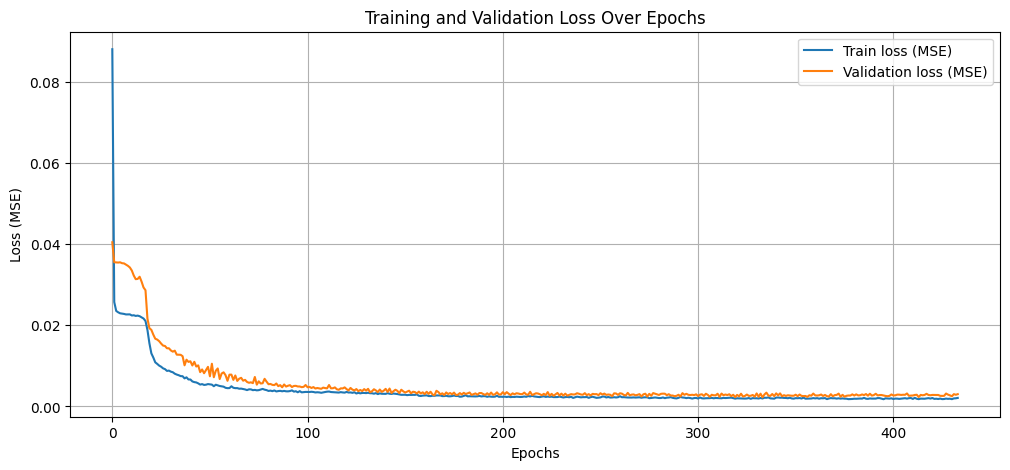

<Figure size 640x480 with 0 Axes>

In [ ]:
modelo, scaler_X, scaler_y, X_test, y_test = train_with_mlflow(
    df_pro = df_filtrado, 
    wins = wins, 
    fore = 1, 
    epochs = epochs, 
    batch_size = batch_size, 
    learning_rate = learning_rate, 
    weight_decay = weight_decay,
    train_test_index = train_test_index, 
    train_val_per = train_val_per
)

Cargo el modelo para no entrenar de nuevo.

## 📦 Verificación de Escaladores y Arquitectura del Modelo

Se muestran los objetos `scaler_X` y `scaler_y`, que contienen los escaladores `MinMaxScaler` ajustados con los datos de entrenamiento para las variables de entrada y salida, respectivamente. También se imprime un resumen de la arquitectura del modelo GRU entrenado mediante el método `.summary()`.

In [ ]:
scaler_X

MinMaxScaler()

In [ ]:
scaler_y

MinMaxScaler()

In [ ]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                        │ (None, 100, 16)             │           1,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 100, 32)             │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,077 (129.21 KB)

 Trainable params: 11,025 (43.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,052 (86.14 KB)

## 🧪 Preparación del Conjunto de Prueba

Se extraen los datos correspondientes al conjunto de prueba a partir del índice temporal definido por `train_test_index`. Esta porción del DataFrame contiene las observaciones no utilizadas durante el entrenamiento ni la validación, y se utilizará para evaluar el rendimiento del modelo en datos no vistos.

> Nota: las líneas comentadas indican pasos previos para escalar el conjunto de prueba y obtener las etiquetas reales a partir de una ventana temporal (`WINDOW_SIZE`).

```python
test_df = df[df['Time'] >= df['Time'].iloc[train_test_index]]
# test_df_scaled_X = pd.DataFrame(scaler_X.transform(test_df[input_variables]), columns=input_variables)
# test_df_scaled_y = pd.DataFrame(scaler_y.transform(test_df[label_variables]), columns=label_variables)
# test_df[label_variables].iloc[WINDOW_SIZE:].values


In [ ]:
test_df = df[df['Time'] >= df['Time'].iloc[train_test_index]]
# test_df_scaled_X = pd.DataFrame(scaler_X.transform(test_df[input_variables]), columns=input_variables)
# test_df_scaled_y = pd.DataFrame(scaler_y.transform(test_df[label_variables]), columns=label_variables)
# test_df[label_variables].iloc[WINDOW_SIZE:].values

## 🔮 Función de Predicción y Visualización de Resultados

Se define la función `predict`, que utiliza el modelo GRU entrenado para realizar predicciones sobre el conjunto de prueba. Las predicciones y los valores reales son desescalados para interpretabilidad, y luego se visualizan comparativamente.

### Funcionalidad:
1. **Predicción paso a paso:** Para los primeros `pred_len` ejemplos del conjunto de prueba, se generan predicciones individualmente.
2. **Desescalado:** Las predicciones y los valores reales se convierten nuevamente a su escala original usando `scaler_y`.
3. **Visualización:** 
   - Se grafican las predicciones de cada señal (`Mooring1`, `Mooring2`, `Mooring3`) frente al tiempo.
   - Se muestran dos gráficos por señal: uno solo con predicción y otro comparando predicción con valor real.
   - Los gráficos se guardan como imágenes en el directorio `./results`.

In [ ]:
def predict(X_test, y_test, modelo, scaler_X, scaler_y, pred_len):
    model = modelo
    acc_pred = []
    acc_real = []
    
    # De forma recurrente, para el tiempo t:
    for i in range(pred_len):
        # Genero la predicción final
        entrada = X_test[i].reshape(1,X_test.shape[1],X_test.shape[2])
        prediccion = model.predict(entrada, verbose = 0)
        prediccion = scaler_y.inverse_transform(prediccion)  # Desescalar las predicciones
        prediccion = np.transpose(prediccion)
        acc_pred.append(prediccion)
        # Genero el correspondiente valor real de salida
        salida = y_test[i]
        real = scaler_y.inverse_transform(salida)  # Desescalar los valores reales
        real = np.transpose(real)
        acc_real.append(real)
        
    acc_pred = np.array(acc_pred)
    acc_real = np.array(acc_real)
    # print(f"Prediccion directa acumulada: {acc_pred}")
    # print(f"Prediccion real acumulada: {acc_real}")
    # print(acc_pred.shape)
    # print(acc_real.shape)
    # print(acc_pred[:,0,:].shape)
    #Tamaño del grafico. Se puede modificar para mostrarlo mas grande o pequeño
    # plt.figure(figsize=(20, 10))
    # for i in range(acc_pred.shape[1]):
    #     plt.figure(figsize=(20, 10))
    #     plt.plot(test_df['Time'][:pred_len], acc_pred[:,i,:], label=f'Mooring {i+1} Predicción', linestyle='--', color='red')

    #     # Graficar los datos reales
    #     # plt.plot(test_df['Time'][:pred_len], acc_real[:,i,:], label='Reales', linestyle='-', color='green')

    #     # Añadir etiquetas y título
    #     plt.xlabel('Tiempo')
    #     plt.ylabel('Mooring')
    #     plt.title('Mooring')
    #     plt.legend() 
    #     plt.grid(True)  # Añadir una rejilla para mejorar la lectura del gráfico
    #     # plt.draw()
    #     plt.show()
        
    
    for i in range(acc_pred.shape[1]):
        plt.figure(figsize=(25, 10))
        plt.plot(test_df['Time'][:pred_len], acc_pred[:,i,:], label=f'Predicted', linestyle='--', color='red', markersize=6)

        # Graficar los datos reales
        plt.plot(test_df['Time'][:pred_len], acc_real[:,i,:], label=f'Simulated', linestyle='-', color='green', markersize=6)

        # Añadir etiquetas y título
        plt.xlabel('Tiempo (segundos)', fontsize=25)
        plt.ylabel('Mooring line tension', fontsize=25)
        plt.title('Mooring line tension prediction', fontsize=28)
        plt.xlim(300,350)
        # Ajustar leyenda y rejilla
        plt.legend(fontsize=25)
        plt.grid(True)
        
        # Ajustar tamaño de las marcas de los ejes
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        
        plt.tight_layout()  # Ajusta automáticamente los márgenes
        # plt.draw()
        # plt.savefig(f"./results/test_pred_{i}_2.png")
        plt.show()
    # print ('Visualizadas todas las predicciones')  
    return acc_pred, acc_real

## 📊 Ejecución de la Predicción y Visualización de Resultados

Se llama a la función `predict` para generar las predicciones del modelo sobre los primeros 1000 puntos del conjunto de prueba (`pred_len = 1000`). La función devuelve las matrices `acc_pred` y `acc_real`, que contienen respectivamente las predicciones y los valores reales desescalados para cada una de las señales de salida. Las predicciones también se visualizan en gráficos y se guardan como imágenes.


In [ ]:
acc_pred, acc_real = predict(X_test, y_test, modelo, scaler_X, scaler_y, pred_len = pred_len)   

IndexError: index 501 is out of bounds for axis 0 with size 501

In [ ]:
for i in range(acc_pred.shape[1]):
    plt.figure(figsize=(10, 10))
    plt.scatter(acc_real[:,i,:], acc_pred[:,i,:], label=f'Predicted', linestyle='--', color='blue')
    plt.plot([acc_real[:,i,:].min(), acc_real[:,i,:].max()], [acc_real[:,i,:].min(), acc_real[:,i,:].max()], 'r--')  # línea ideal
    # Añadir etiquetas y título
    plt.xlabel(f'Simulated mooring line {i+1} tension', fontsize=18)
    plt.ylabel(f'Predicted mooring line {i+1} tension', fontsize=18)
    plt.title('Simulated vs predicted data', fontsize=20)
    # plt.legend() 
    plt.grid(True)  # Añadir una rejilla para mejorar la lectura del gráfico
    # plt.draw()
    # plt.savefig(f"./results/test_pred_{i}_2.png")
    plt.show()

Problema: la predicción, aunque del orden de los valores reales, no 
Posibles soluciones (en orden de prioridad): <br>
¿Tendrá que ver con la normalización? ¿Outliers? Ver gráficas y comprobar (valores normalizados en train y normalizacion y si lo que predice se está desescalando de verdad). <br>
Ventana pequeña. Corregido dado que  <br>
¿Será porque tiene un learning_rate inadecuado? Es el que figura en el artículo... un learning_rate de 0.01 lo veo normal.  <br>
Podría ser que el batch_size no sea el adecuado para series temporales, ya que su configuración convencional podría estar "rompiendo" las ventanas de datos. Una opción más robusta sería utilizar tf.keras.utils.timeseries_dataset_from_array, ya que maneja el batch_size asegurando la integridad de las ventanas (por ejemplo, agrupando conjuntos completos de ventanas en cada lote). Sin embargo, su configuración puede ser más compleja. Dado que el formato de ambos es (batch, time, features) lo más seguro es que esto se haga bien con ambos. **DESCARTADO** <br>
Quitar ruido a los datos para que solo aprenda la tendencia general (se puede complicar mucho). <br>

Registro: <br>
Batch bajo no funciona, probar 128 o más <br>
